*** install requirements and import ***

pip install -r requirements.txt

Vælg: /usr/local/python/3.12.1/bin/python

In [14]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Week 1**

In [15]:
# Brug af det nutidige API
api_nutidig = "https://data.sfgov.org/resource/wg3w-h783.json"

# Vi henter f.eks. de første 100.000 rækker for at få et godt overblik (det tager lidt længere tid, men det er nødvendigt for at få et repræsentativt datasæt)
# Note: der er mere end 100.000 rækker i det nutidige API, så vi kan overveje at hente flere data senere, hvis det er nødvendigt
response = requests.get(f"{api_nutidig}?$limit=100000")
data = response.json()
df_now = pd.DataFrame(data)

print(f"Datasættet har {df_now.shape[0]} rækker og {df_now.shape[1]} kolonner.")

Datasættet har 100000 rækker og 36 kolonner.


In [16]:
# Se de første rækker
print(df_now.head())

# Tæl de mest almindelige kategorier
top_crimes = df_now['incident_category'].value_counts().head(10)
print("\nTop 10 Kriminalitetskategorier:")
print(top_crimes)

         row_id        incident_datetime            incident_date  \
0  152278216710  2025-10-31T17:55:00.000  2025-10-31T00:00:00.000   
1  148998204134  2025-06-13T12:41:00.000  2025-06-13T00:00:00.000   
2  152328663010  2025-11-03T14:00:00.000  2025-11-03T00:00:00.000   
3  149000206224  2025-05-21T00:00:00.000  2025-05-21T00:00:00.000   
4  152326906304  2025-10-23T00:00:00.000  2025-10-23T00:00:00.000   

  incident_time incident_year incident_day_of_week          report_datetime  \
0         17:55          2025               Friday  2025-10-31T17:55:00.000   
1         12:41          2025               Friday  2025-06-13T12:46:00.000   
2         14:00          2025               Monday  2025-11-03T14:00:00.000   
3         00:00          2025            Wednesday  2025-05-21T08:15:00.000   
4         00:00          2025             Thursday  2025-11-03T13:24:00.000   

  incident_id incident_number cad_number  ...               data_as_of  \
0     1522782       250613625  25304

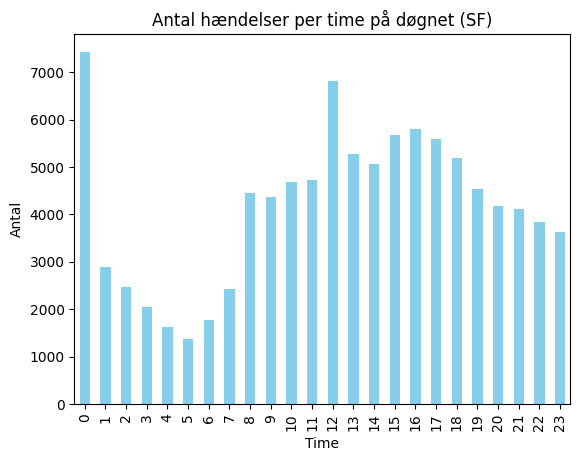

In [17]:
# Konverter tid til datetime
df_now['incident_time'] = pd.to_datetime(df_now['incident_time'], format='%H:%M').dt.hour

# Plot antal hændelser per time
df_now['incident_time'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Antal hændelser per time på døgnet (SF)')
plt.xlabel('Time')
plt.ylabel('Antal')
plt.savefig('week1.png')
plt.show()

**Week 2**

In [18]:
api_historisk = "https://data.sfgov.org/resource/tmnf-yvry.json"
res_hist = requests.get(f"{api_historisk}?$limit=100000")
df_hist = pd.DataFrame(res_hist.json())

print(f"Historisk datasæt hentet: {df_hist.shape[0]} rækker.")

Historisk datasæt hentet: 100000 rækker.


In [19]:
# Eksempel på mapping (Kategori-navne kan variere lidt i API'erne)
# Vi ensretter kolonnenavne
df_hist = df_hist.rename(columns={'category': 'incident_category', 'date': 'incident_date'})

# Kombiner de to datasæt
df_combined = pd.concat([df_hist[['incident_category', 'incident_date']], 
                         df_now[['incident_category', 'incident_date']]], axis=0)

print(f"Samlet datasæt størrelse: {df_combined.shape}")

Samlet datasæt størrelse: (200000, 2)


**Week 3**

In [20]:
# Vi kigger på Larceny/Theft i forhold til distrikter
crime_district = pd.crosstab(df_now['police_district'], df_now['incident_category'])

# Normaliser for at få proportioner (betinget sandsynlighed)
crime_district_norm = crime_district.div(crime_district.sum(axis=1), axis=0)

# Vis de 5 mest almindelige forbrydelser i et bestemt distrikt (f.eks. Central)
print("Top forbrydelser i Central District (Proportioner):")
print(crime_district_norm.loc['Central'].sort_values(ascending=False).head(5))

Top forbrydelser i Central District (Proportioner):
incident_category
Larceny Theft          0.284388
Assault                0.078015
Malicious Mischief     0.076408
Other Miscellaneous    0.066946
Lost Property          0.052932
Name: Central, dtype: float64


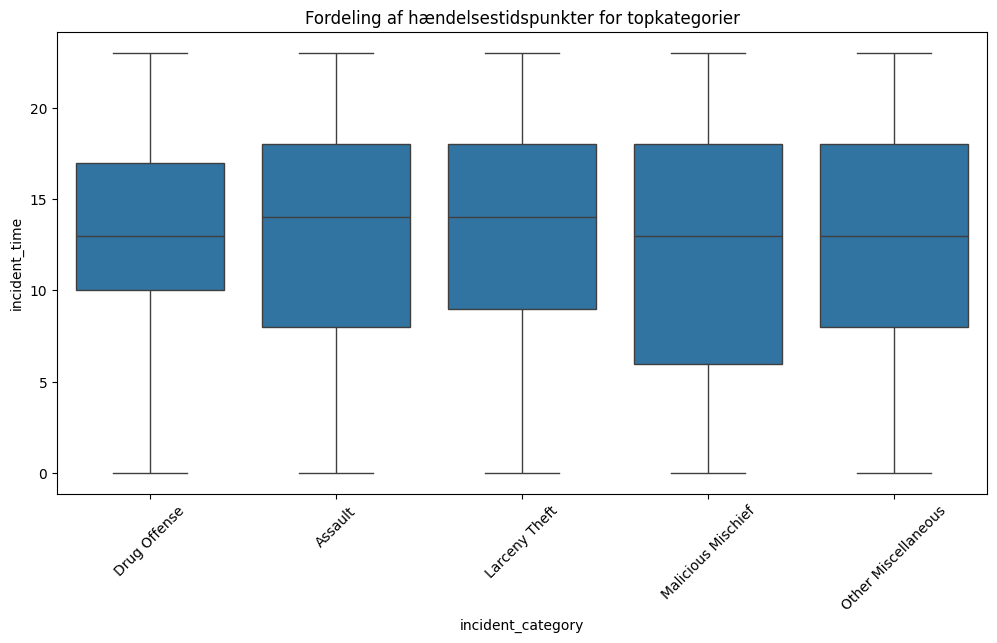

In [21]:
# Vi fokuserer på de 5 største kategorier
import seaborn as sns

top_5_categories = df_now['incident_category'].value_counts().head(5).index
df_subset = df_now[df_now['incident_category'].isin(top_5_categories)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='incident_category', y='incident_time', data=df_subset)
plt.xticks(rotation=45)
plt.title('Fordeling af hændelsestidspunkter for topkategorier')
plt.savefig('week3.png')
plt.show()

**Week 4**

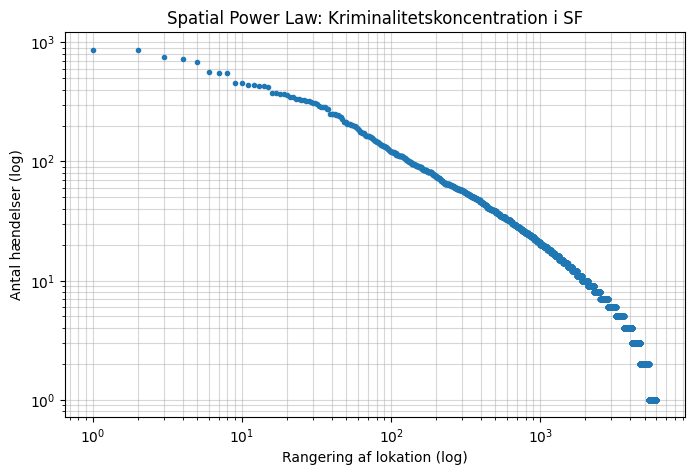

In [22]:
import numpy as np

# Vi tæller hændelser per lokation (lat/lon par)
location_counts = df_now.groupby(['latitude', 'longitude']).size().sort_values(ascending=False)

# Lav log-log plot
plt.figure(figsize=(8, 5))
plt.loglog(np.arange(len(location_counts)) + 1, location_counts.values, marker='.', linestyle='none')
plt.title('Spatial Power Law: Kriminalitetskoncentration i SF')
plt.xlabel('Rangering af lokation (log)')
plt.ylabel('Antal hændelser (log)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.savefig('week4.png')
plt.show()

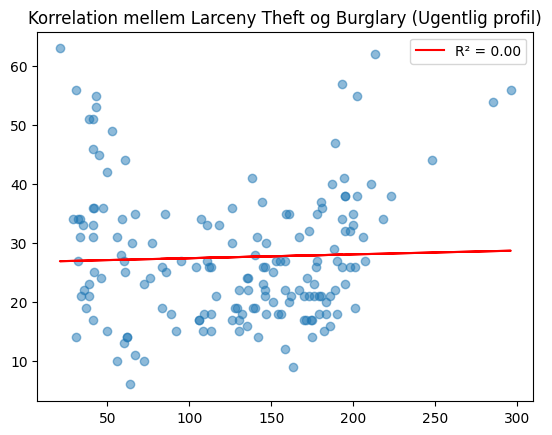

: 

In [ ]:
from scipy.stats import linregress

# Vi laver en tidsserie over timer i ugen (0-167) for to typer
def get_weekly_profile(crime_type):
    subset = df_now[df_now['incident_category'] == crime_type]
    # Simpel gruppering efter ugedag og time
    return subset.groupby(['incident_day_of_week', 'incident_time']).size().values

# Eksempel med to kategorier
x = get_weekly_profile('Larceny Theft')
y = get_weekly_profile('Burglary')

# Kør regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

plt.scatter(x, y, alpha=0.5)
plt.plot(x, intercept + slope*x, 'r', label=f'R² = {r_value**2:.2f}')
plt.legend()
plt.title('Korrelation mellem Larceny Theft og Burglary (Ugentlig profil)')
plt.savefig('week4(1).png')
plt.show()

**Week 5**

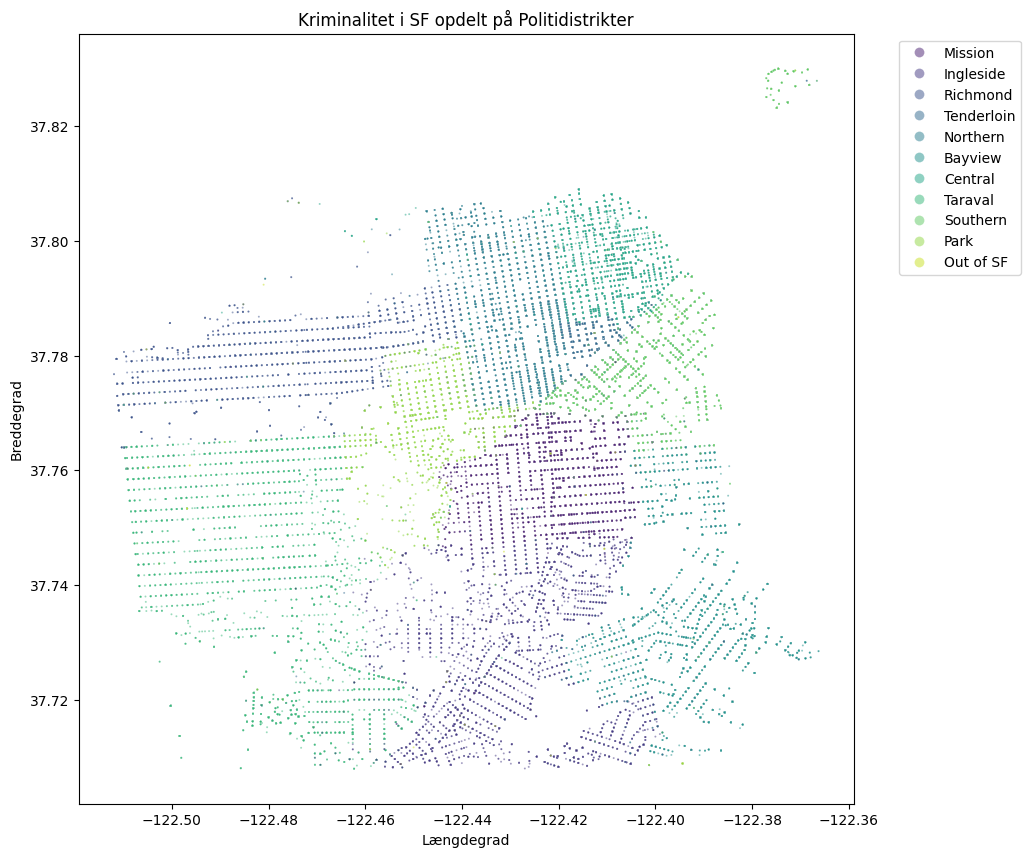

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vi filtrerer eventuelle manglende koordinater fra
df_geo = df_now.dropna(subset=['latitude', 'longitude'])

# Sørg for at koordinater er tal
df_geo['latitude'] = df_geo['latitude'].astype(float)
df_geo['longitude'] = df_geo['longitude'].astype(float)

plt.figure(figsize=(10, 10))
# Vi bruger s=1 for at gøre punkterne små, så de ikke overlapper for meget
sns.scatterplot(data=df_geo, x='longitude', y='latitude', 
                hue='police_district', s=2, alpha=0.5, palette='viridis')

plt.title('Kriminalitet i SF opdelt på Politidistrikter')
plt.xlabel('Længdegrad')
plt.ylabel('Breddegrad')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=5)
plt.savefig('week5.png')
plt.show()

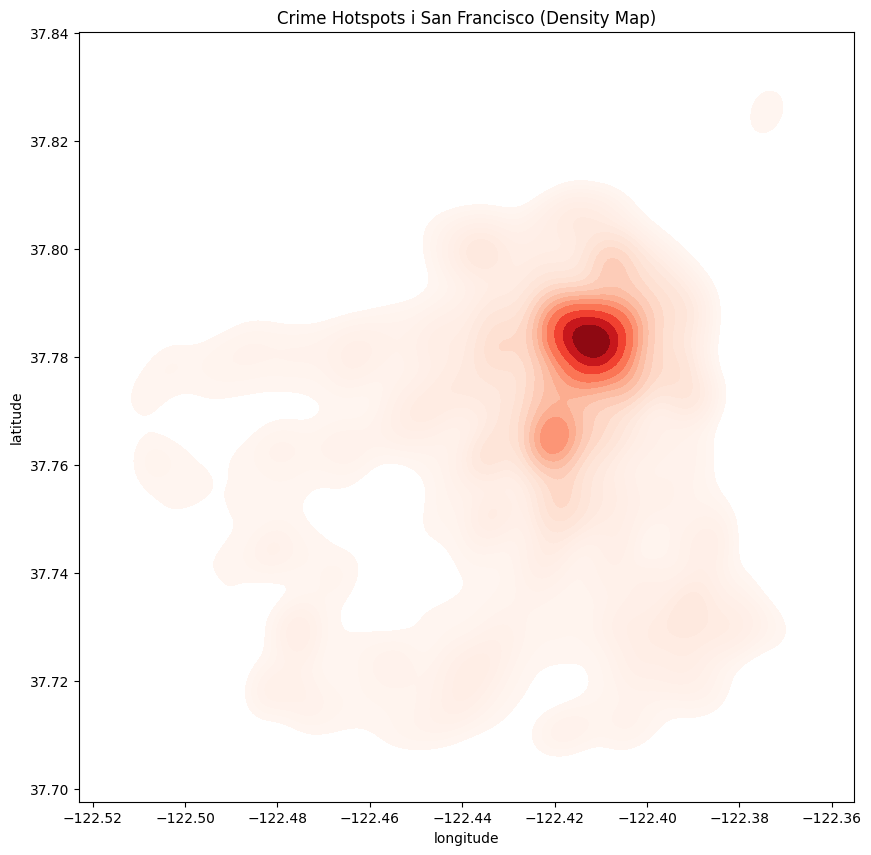

In [25]:
plt.figure(figsize=(10, 10))

# Vi tegner tætheden af hændelser
sns.kdeplot(data=df_geo, x='longitude', y='latitude', 
            fill=True, cmap='Reds', thresh=0.05, levels=20)

plt.title('Crime Hotspots i San Francisco (Density Map)')
plt.savefig('week5(1).png')
plt.show()

**Week 6**

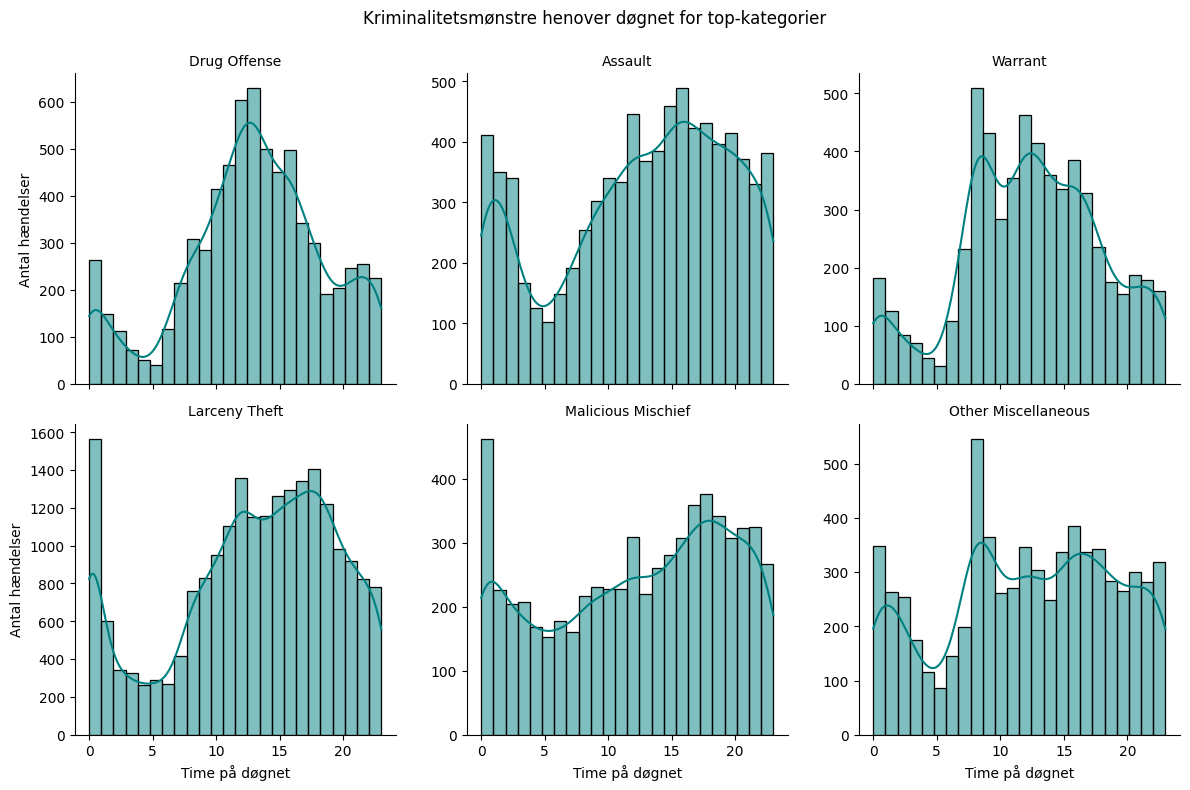

In [26]:
# Vi vælger de top 6 mest almindelige forbrydelser
top_6 = df_now['incident_category'].value_counts().head(6).index
df_top = df_now[df_now['incident_category'].isin(top_6)]

# Opretter et gitter af grafer (Small Multiples)
g = sns.FacetGrid(df_top, col="incident_category", col_wrap=3, height=4, sharey=False)
g.map(sns.histplot, "incident_time", bins=24, kde=True, color="teal")

g.set_axis_labels("Time på døgnet", "Antal hændelser")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Kriminalitetsmønstre henover døgnet for top-kategorier')
plt.savefig('week6.png')
plt.show()